In [393]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

RANDOM_STATE = 67
np.random.seed(RANDOM_STATE)


Задача 1


In [394]:
df_raw = pd.read_csv('student_lifestyle_100k.csv')

print(f"Размер: {df_raw.shape[0]} строк {df_raw.shape[1]} столбцов")
print("Типы данных:")
print(df_raw.dtypes)


Размер: 100000 строк 11 столбцов
Типы данных:
Student_ID              int64
Age                     int64
Gender                    str
Department                str
CGPA                  float64
Sleep_Duration        float64
Study_Hours           float64
Social_Media_Hours    float64
Physical_Activity       int64
Stress_Level            int64
Depression               bool
dtype: object


In [395]:
df_raw.head()


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [396]:
df_raw.describe().round(3)


,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000
mean,51000.500,21.009,2.898,6.996,4.510,3.503,74.353,4.132
std,28867.658,2.000,0.532,1.499,1.976,1.487,43.367,1.424
min,1001.000,18.000,1.560,3.000,0.000,0.000,0.000,2.000
25%,26000.750,19.000,2.450,6.000,3.200,2.500,37.000,3.000
50%,51000.500,21.000,2.900,7.000,4.500,3.500,74.000,4.000
75%,76000.250,23.000,3.350,8.000,5.800,4.500,112.000,5.000
max,101000.000,24.000,4.000,12.000,12.800,10.000,149.000,10.000


In [397]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

missing_df = pd.DataFrame({
    'Пропусков': missing
}).sort_values('Пропусков', ascending=False)

print(missing_df)


                    Пропусков
Student_ID                  0
Age                         0
Gender                      0
Department                  0
CGPA                        0
Sleep_Duration              0
Study_Hours                 0
Social_Media_Hours          0
Physical_Activity           0
Stress_Level                0
Depression                  0


Пропусков нет. Описание датасета на kaggle не соврало

In [398]:
n_dup = df_raw.duplicated().sum()
print(f"Полных дубликатов: {n_dup}")

num_cols = ['Age', 'CGPA', 'Sleep_Duration', 'Study_Hours',
            'Social_Media_Hours', 'Physical_Activity', 'Stress_Level']

for col in num_cols:
    n_neg = (df_raw[col] < 0).sum()
    print(f"{col}: min={df_raw[col].min():.2f}, max={df_raw[col].max():.2f}, отрицательных={n_neg}")

print()
print(f"CGPA > 4.0: {(df_raw['CGPA'] > 4.0).sum()}")
print(f"Age < 16 или > 40: {((df_raw['Age'] < 16) | (df_raw['Age'] > 40)).sum()}")
print(f"Sleep_Duration < 2 или > 14: {((df_raw['Sleep_Duration'] < 2) | (df_raw['Sleep_Duration'] > 14)).sum()}")
print(f"Study_Hours < 0 или > 20: {((df_raw['Study_Hours'] < 0) | (df_raw['Study_Hours'] > 20)).sum()}")


Полных дубликатов: 0
Age: min=18.00, max=24.00, отрицательных=0
CGPA: min=1.56, max=4.00, отрицательных=0
Sleep_Duration: min=3.00, max=12.00, отрицательных=0
Study_Hours: min=0.00, max=12.80, отрицательных=0
Social_Media_Hours: min=0.00, max=10.00, отрицательных=0
Physical_Activity: min=0.00, max=149.00, отрицательных=0
Stress_Level: min=2.00, max=10.00, отрицательных=0

CGPA > 4.0: 0
Age < 16 или > 40: 0
Sleep_Duration < 2 или > 14: 0
Study_Hours < 0 или > 20: 0


Дубликатов нет. Описание датасета на kaggle не соврало и здесь.
Логически неправильных значений тоже нет.

In [399]:
df_raw['Physical_Activity'] = df_raw['Physical_Activity'] / 60.0 / 168.0

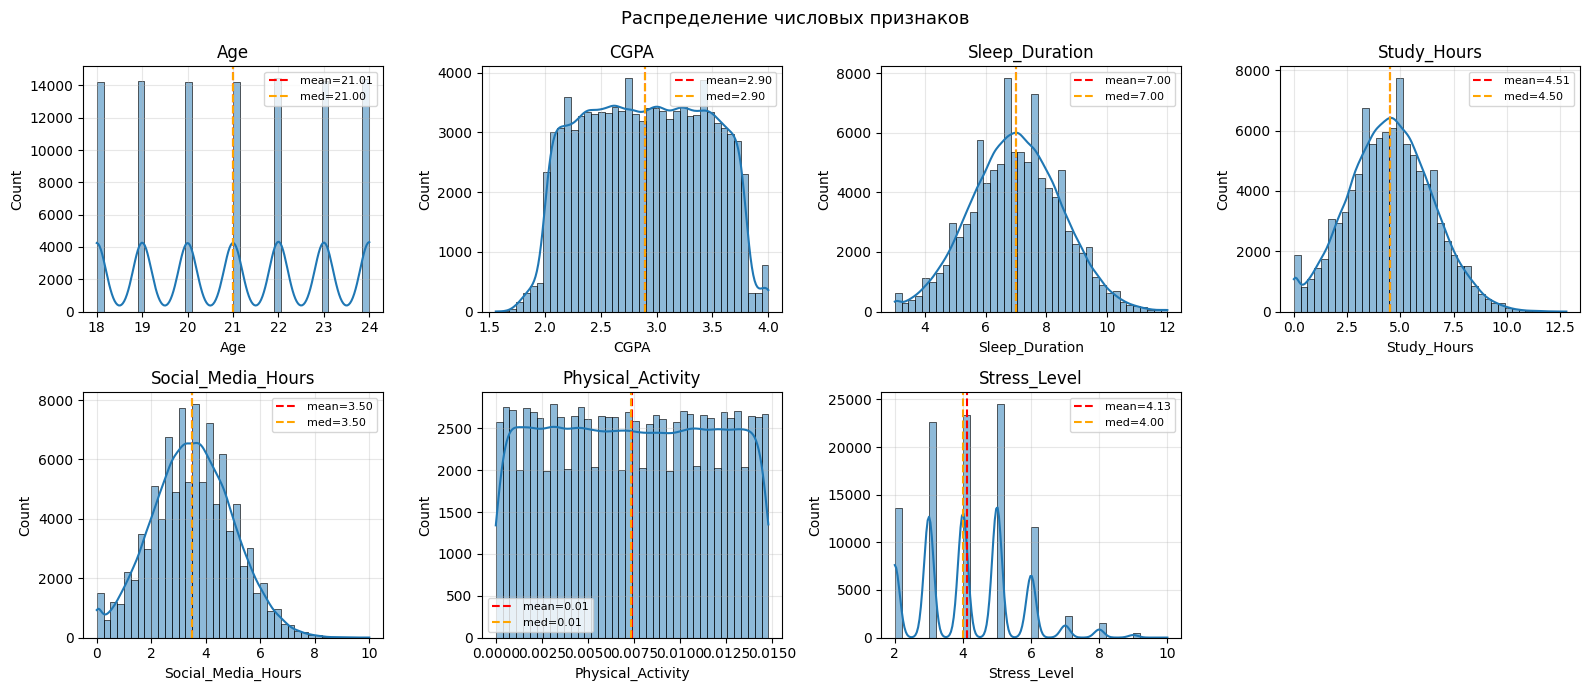

In [400]:
num_cols_plot = ['Age', 'CGPA', 'Sleep_Duration', 'Study_Hours',
                 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols_plot):
    ax = axes[i]
    data = df_raw[col].dropna()
    sns.histplot(data, bins=40, ax=ax, kde=True)
    ax.axvline(data.mean(), color='red', lw=1.5, linestyle='--', label=f'mean={data.mean():.2f}')
    ax.axvline(data.median(), color='orange', lw=1.5, linestyle='--', label=f'med={data.median():.2f}')
    ax.set_title(col)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('Распределение числовых признаков', fontsize=13)
plt.tight_layout()
plt.show()


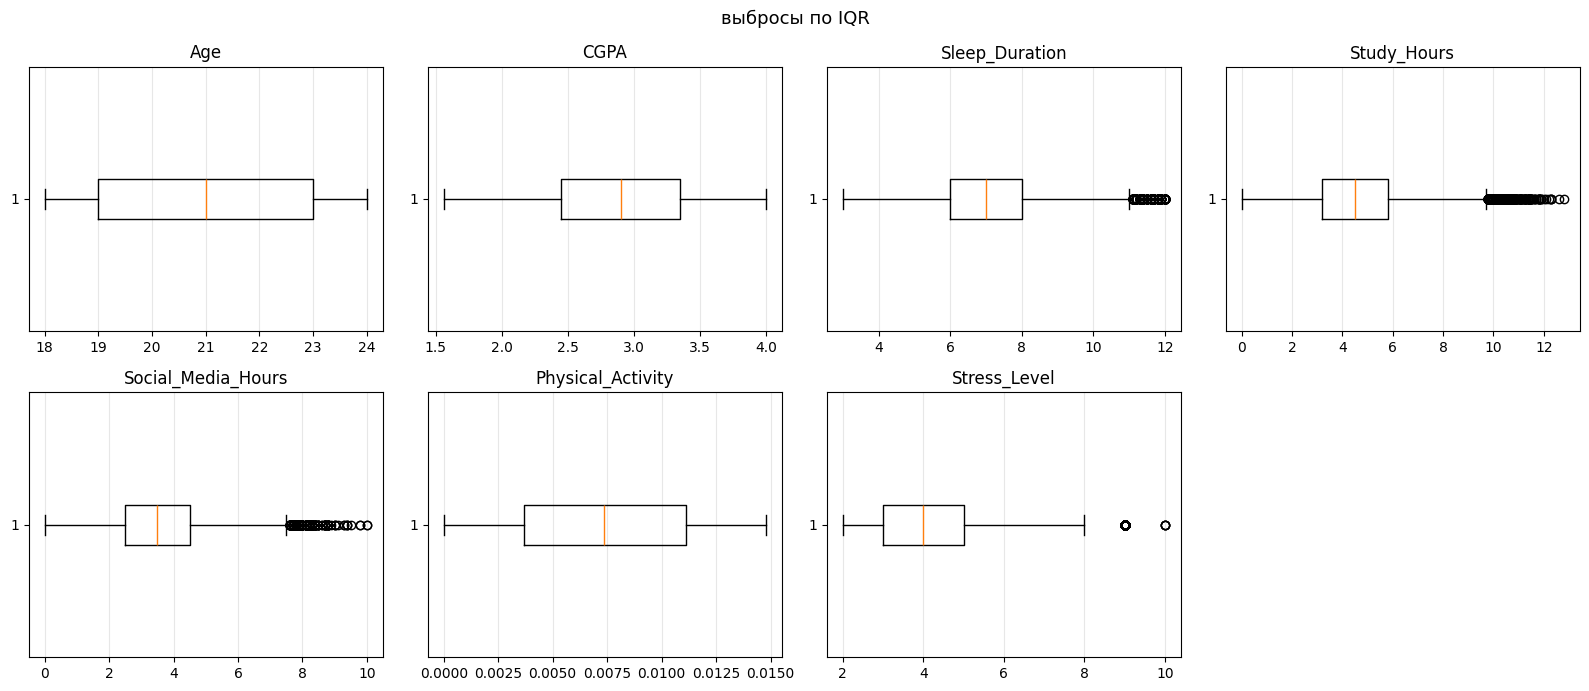

Количество выбросов по IQR-методу:
Age                      :     0 (0.00%)
CGPA                     :     0 (0.00%)
Sleep_Duration           :   369 (0.37%)
Study_Hours              :   432 (0.43%)
Social_Media_Hours       :   328 (0.33%)
Physical_Activity        :     0 (0.00%)
Stress_Level             :   478 (0.48%)


In [401]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols_plot):
    ax = axes[i]
    ax.boxplot(df_raw[col].dropna(), vert=False)
    ax.set_title(col)
    ax.grid(True, alpha=0.3, axis='x')

axes[-1].set_visible(False)
plt.suptitle('выбросы по IQR', fontsize=13)
plt.tight_layout()
plt.show()

print("Количество выбросов по IQR-методу:")
for col in num_cols_plot:
    data = df_raw[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    print(f"{col:25s}: {n_out:5d} ({n_out/len(data)*100:.2f}%)")


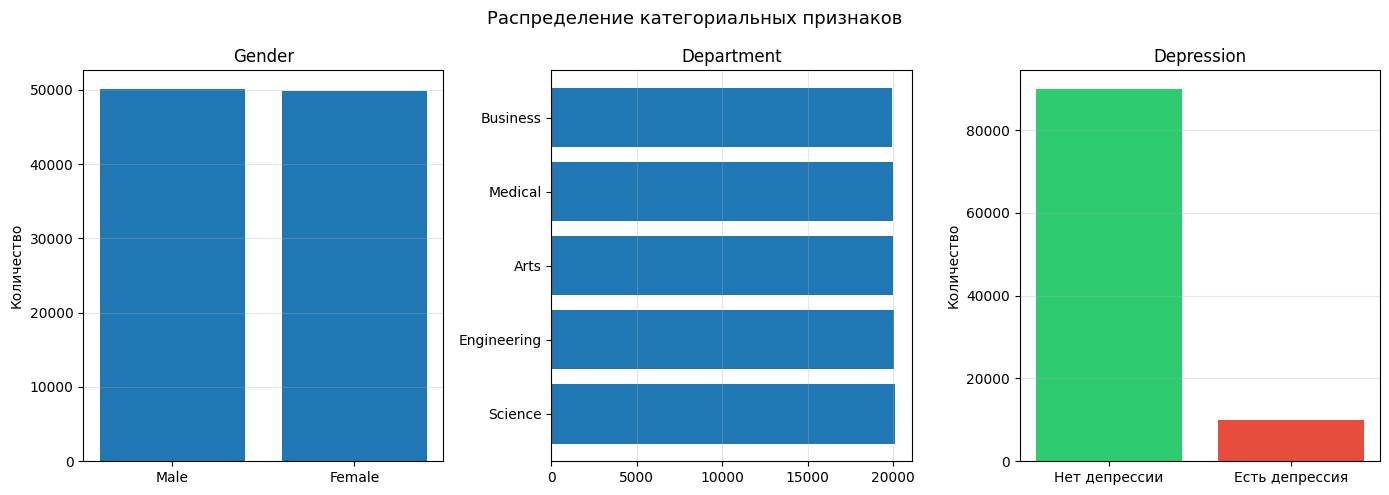

In [402]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

gender_counts = df_raw['Gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values)
axes[0].set_title('Gender')
axes[0].set_ylabel('Количество')
axes[0].grid(True, alpha=0.3, axis='y')

dept_counts = df_raw['Department'].value_counts()
axes[1].barh(dept_counts.index, dept_counts.values)
axes[1].set_title('Department')
axes[1].grid(True, alpha=0.3, axis='x')

dep_counts = df_raw['Depression'].value_counts()
axes[2].bar(['Нет депрессии', 'Есть депрессия'], dep_counts.values,
            color=['#2ecc71', '#e74c3c'])
axes[2].set_title('Depression')
axes[2].set_ylabel('Количество')
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Распределение категориальных признаков', fontsize=13)
plt.tight_layout()
plt.show()


CGPA: mean=2.898, std=0.532, min=1.56, max=4.00


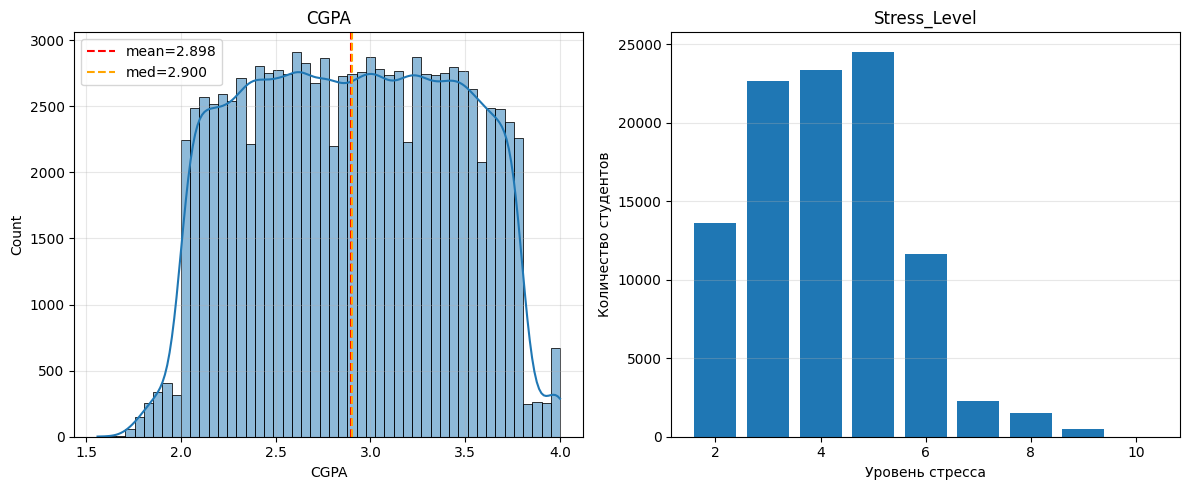

In [403]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

data_cgpa = df_raw['CGPA'].dropna()
sns.histplot(data_cgpa, bins=50, ax=axes[0], kde=True)
axes[0].axvline(data_cgpa.mean(), color='red', lw=1.5, linestyle='--',
                label=f'mean={data_cgpa.mean():.3f}')
axes[0].axvline(data_cgpa.median(), color='orange', lw=1.5, linestyle='--',
                label=f'med={data_cgpa.median():.3f}')
axes[0].set_title('CGPA')
axes[0].set_xlabel('CGPA')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
print(f"CGPA: mean={data_cgpa.mean():.3f}, std={data_cgpa.std():.3f}, "
      f"min={data_cgpa.min():.2f}, max={data_cgpa.max():.2f}")

stress_counts = df_raw['Stress_Level'].value_counts().sort_index()
axes[1].bar(stress_counts.index, stress_counts.values)
axes[1].set_title('Stress_Level')
axes[1].set_xlabel('Уровень стресса')
axes[1].set_ylabel('Количество студентов')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


C:\Users\petre\AppData\Local\Temp\ipykernel_26240\1756996296.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(dep_groups, labels=['Нет депрессии', 'Есть депрессия'])


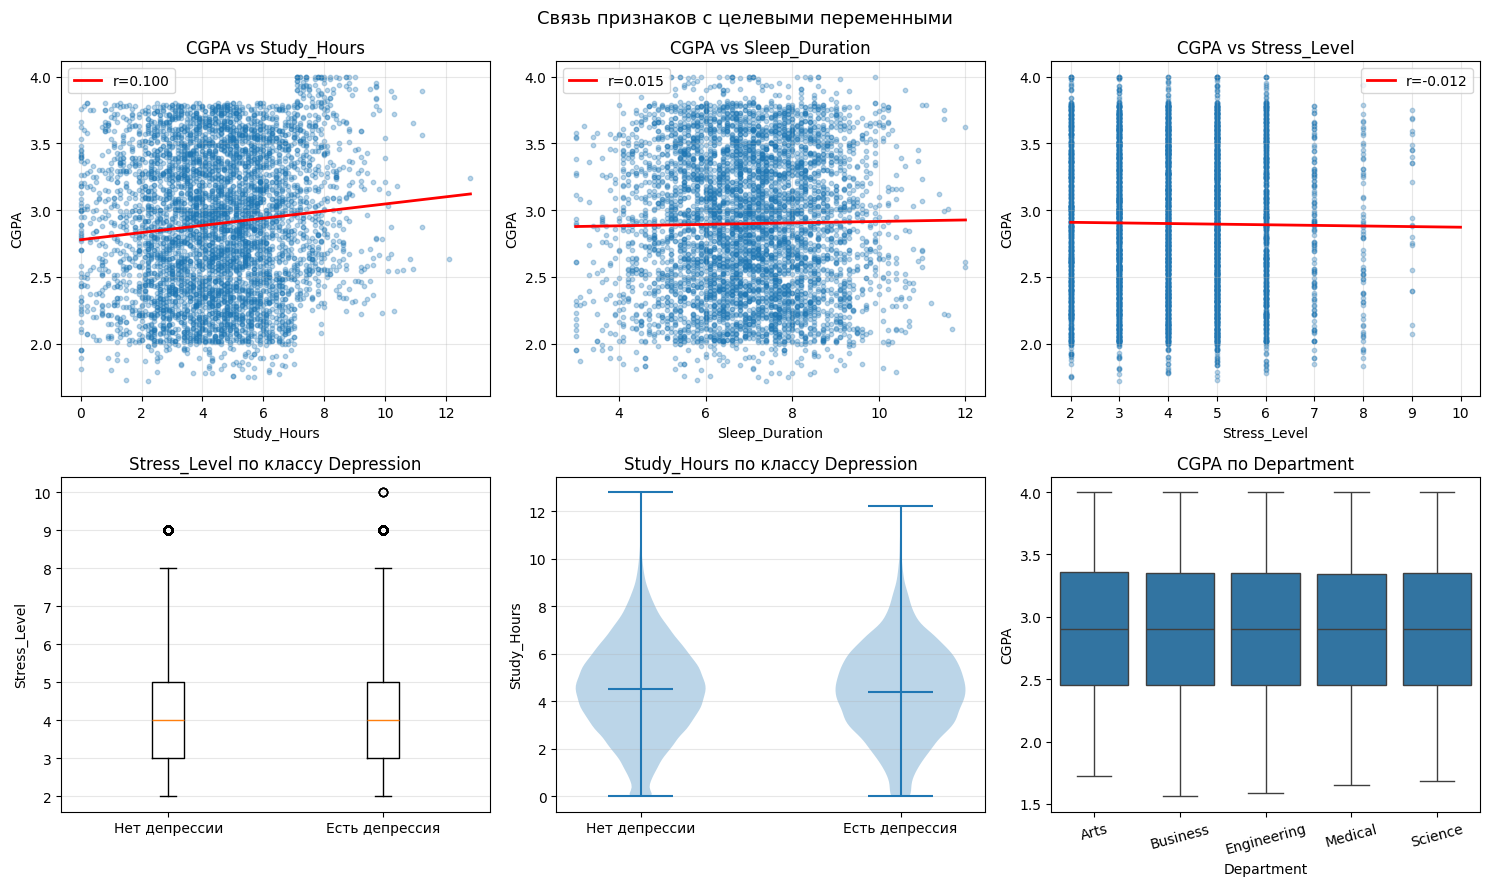

In [404]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
sample = df_raw.sample(5000, random_state=RANDOM_STATE)

for i, xcol in enumerate(['Study_Hours', 'Sleep_Duration', 'Stress_Level']):
    ax = axes[0, i]
    ax.scatter(sample[xcol], sample['CGPA'], alpha=0.3, s=10)
    z = np.polyfit(df_raw[xcol].dropna(), df_raw['CGPA'].dropna(), 1)
    xl = np.linspace(df_raw[xcol].min(), df_raw[xcol].max(), 100)
    r = df_raw[xcol].corr(df_raw['CGPA'])
    ax.plot(xl, np.poly1d(z)(xl), 'r-', lw=2, label=f'r={r:.3f}')
    ax.set_xlabel(xcol)
    ax.set_ylabel('CGPA')
    ax.set_title(f'CGPA vs {xcol}')
    ax.legend()
    ax.grid(True, alpha=0.3)

ax = axes[1, 0]
dep_groups = [df_raw[df_raw['Depression'] == v]['Stress_Level'] for v in [False, True]]
ax.boxplot(dep_groups, labels=['Нет депрессии', 'Есть депрессия'])
ax.set_ylabel('Stress_Level')
ax.set_title('Stress_Level по классу Depression')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 1]
ax.violinplot([df_raw[df_raw['Depression'] == v]['Study_Hours'] for v in [False, True]],
              positions=[0, 1], showmedians=True)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Нет депрессии', 'Есть депрессия'])
ax.set_ylabel('Study_Hours')
ax.set_title('Study_Hours по классу Depression')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 2]
dept_order = df_raw.groupby('Department')['CGPA'].median().sort_values().index.tolist()
sns.boxplot(data=df_raw, x='Department', y='CGPA', order=dept_order, ax=ax)
ax.set_title('CGPA по Department')
ax.tick_params(axis='x', rotation=15)

plt.suptitle('Связь признаков с целевыми переменными', fontsize=13)
plt.tight_layout()
plt.show()


In [405]:
df = df_raw.copy()
print(df.shape)
df = df.drop(columns=['Student_ID'])

df['Depression'] = df['Depression'].astype(int)
print(df['Depression'].value_counts().to_dict())


(100000, 11)
{0: 89938, 1: 10062}


In [406]:
clip_cols = ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours',
             'Physical_Activity', 'Stress_Level']

for col in clip_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = max(0, Q1 - 1.5 * IQR)
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower, upper)
    print(f"{col}: clip [{lower:.2f}, {upper:.2f}] ограничено {n_out}")


Sleep_Duration: clip [3.00, 11.00] ограничено 369
Study_Hours: clip [0.00, 9.70] ограничено 432
Social_Media_Hours: clip [0.00, 7.50] ограничено 328
Physical_Activity: clip [0.00, 0.02] ограничено 0
Stress_Level: clip [0.00, 8.00] ограничено 478


In [407]:

df['Gender_Enc'] = (df['Gender'] == 'Male').astype(int)
print(df['Gender_Enc'].value_counts().to_dict())

dept_dummies = pd.get_dummies(df['Department'], prefix='Dept', drop_first=True)
df = pd.concat([df, dept_dummies], axis=1)
print(list(dept_dummies.columns))

df = df.drop(columns=['Gender', 'Department'])
print(f"Итоговые столбцы: {df.columns.tolist()}")


{1: 50120, 0: 49880}
['Dept_Business', 'Dept_Engineering', 'Dept_Medical', 'Dept_Science']
Итоговые столбцы: ['Age', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level', 'Depression', 'Gender_Enc', 'Dept_Business', 'Dept_Engineering', 'Dept_Medical', 'Dept_Science']


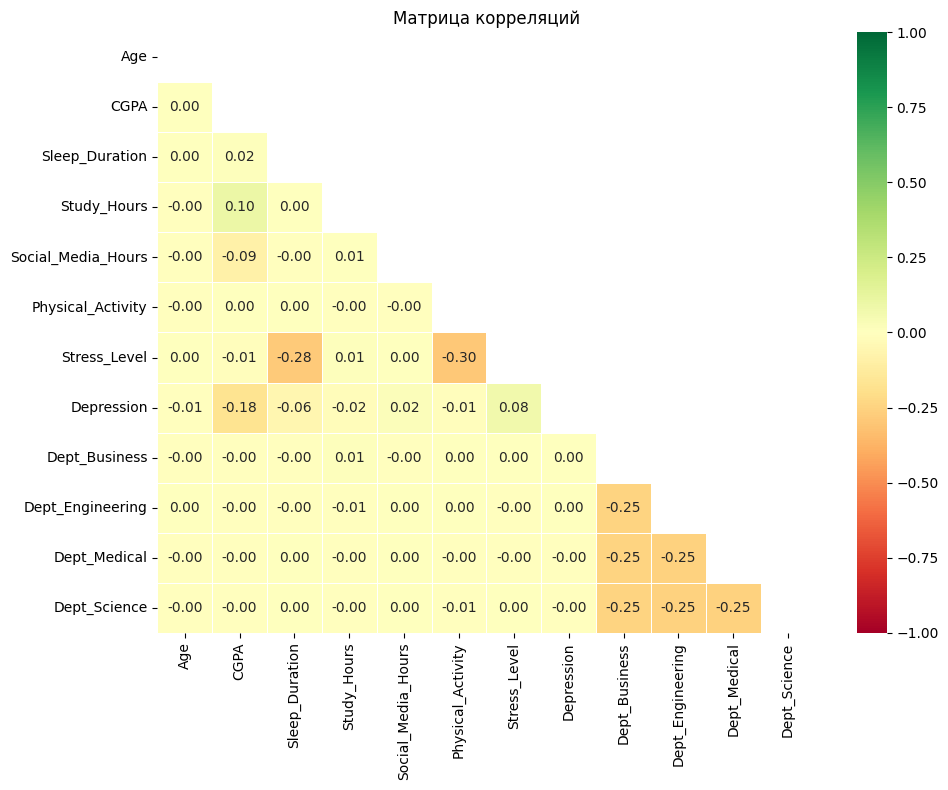

Корреляция с CGPA:
Depression               : -0.1790
Study_Hours              : +0.0995
Social_Media_Hours       : -0.0880
Sleep_Duration           : +0.0154
Stress_Level             : -0.0123
Physical_Activity        : +0.0048
Age                      : +0.0032
Dept_Medical             : -0.0021
Dept_Engineering         : -0.0011
Dept_Business            : -0.0006
Dept_Science             : -0.0003

Корреляция с Depression:
CGPA                     : -0.1790
Stress_Level             : +0.0759
Sleep_Duration           : -0.0575
Social_Media_Hours       : +0.0168
Study_Hours              : -0.0159
Physical_Activity        : -0.0139
Age                      : -0.0077
Dept_Business            : +0.0021
Dept_Science             : -0.0019
Dept_Medical             : -0.0018
Dept_Engineering         : +0.0002


In [408]:
dept_cols = [c for c in df.columns if c.startswith('Dept_')]

df_corr = df_raw[num_cols_plot + ['Depression']].copy()
df_corr['Depression'] = df_corr['Depression'].astype(int)
for col in dept_cols:
    df_corr[col] = df[col].values

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Матрица корреляций')
plt.tight_layout()
plt.show()

print("Корреляция с CGPA:")
cgpa_corr = corr_matrix['CGPA'].drop('CGPA').sort_values(key=abs, ascending=False)
for feat, val in cgpa_corr.items():
    print(f"{feat:25s}: {val:+.4f}")

print()
print("Корреляция с Depression:")
dep_corr = corr_matrix['Depression'].drop('Depression').sort_values(key=abs, ascending=False)
for feat, val in dep_corr.items():
    print(f"{feat:25s}: {val:+.4f}")


Задача 4

In [409]:
df['Study_Sleep_Ratio'] = df['Study_Hours'] / (df['Sleep_Duration'] + 1)
df['Study_Efficiency'] = df['Study_Hours'] / (df['Social_Media_Hours'] + 1)
df['Sleep_Deficit'] = 8.0 - df['Sleep_Duration']
df['Productive_Hours'] = df['Study_Hours'] + df['Physical_Activity'] / 60
df['Optimal_Sleep'] = (df['Sleep_Duration'] >= 6) & (df['Sleep_Duration'] <= 9)
df['Stress_Sleep_Gap'] = (df['Stress_Level'] / 10) - (df['Sleep_Duration'] / 14)
df['Total_Screen_Hours'] = df['Study_Hours'] + df['Social_Media_Hours']
df['Study_Social_diff'] = df['Study_Hours'] - df['Social_Media_Hours']
new_feats = ['Study_Sleep_Ratio', 'Productive_Hours', 'Stress_Sleep_Gap', 'Total_Screen_Hours', 'Study_Social_diff', 'Study_Efficiency', 'Sleep_Deficit', 'Optimal_Sleep']
print(df[new_feats].describe().round(3))


       Study_Sleep_Ratio  Productive_Hours  Stress_Sleep_Gap  \
count         100000.000        100000.000        100000.000   
mean               0.585             4.507            -0.087   
std                0.288             1.967             0.199   
min                0.000             0.000            -0.586   
25%                0.387             3.200            -0.221   
50%                0.562             4.500            -0.107   
75%                0.756             5.800             0.021   
max                2.425             9.700             0.586   

       Total_Screen_Hours  Study_Social_diff  Study_Efficiency  Sleep_Deficit  
count          100000.000         100000.000        100000.000     100000.000  
mean                8.008              1.005             1.165          1.005  
std                 2.469              2.457             0.829          1.493  
min                 0.000             -7.500             0.000         -3.000  
25%                 6.3

In [410]:
print("Корреляция новых признаков с CGPA:")
for f in new_feats:
    r = df[f].corr(df['CGPA'])
    print(f"{f}: {r:+.4f}")

print()
print("Корреляция новых признаков с Depression:")
for f in new_feats:
    r = df[f].corr(df['Depression'])
    print(f"{f:}: {r:+.4f}")


Корреляция новых признаков с CGPA:
Study_Sleep_Ratio: +0.0788
Productive_Hours: +0.0993
Stress_Sleep_Gap: -0.0169
Total_Screen_Hours: +0.0262
Study_Social_diff: +0.1326
Study_Efficiency: +0.0969
Sleep_Deficit: -0.0153
Optimal_Sleep: +0.0110

Корреляция новых признаков с Depression:
Study_Sleep_Ratio: +0.0166
Productive_Hours: -0.0160
Stress_Sleep_Gap: +0.0825
Total_Screen_Hours: -0.0026
Study_Social_diff: -0.0230
Study_Efficiency: -0.0175
Sleep_Deficit: +0.0577
Optimal_Sleep: -0.0359


In [411]:
TARGET_REG = 'CGPA'
FEATURES_REG = [
    'Study_Hours', 'Study_Efficiency',
    'Productive_Hours', 'Social_Media_Hours',
    'Study_Sleep_Ratio'
]

TARGET_CLF = 'Depression'

FEATURES_CLF = [
    'Stress_Sleep_Gap', 'Stress_Level',
    'Sleep_Duration', 'Sleep_Deficit'
]

print("Linear Regression:", FEATURES_REG)
print("Logistic Regression:", FEATURES_CLF)


Linear Regression: ['Study_Hours', 'Study_Efficiency', 'Productive_Hours', 'Social_Media_Hours', 'Study_Sleep_Ratio']
Logistic Regression: ['Stress_Sleep_Gap', 'Stress_Level', 'Sleep_Duration', 'Sleep_Deficit']


Задача 4

In [412]:
X_reg = df[FEATURES_REG].values
y_reg = df[TARGET_REG].values

X_reg_tv, X_reg_test, y_reg_tv, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.15, random_state=RANDOM_STATE
)
X_reg_train, X_reg_val, y_reg_train, y_reg_val = train_test_split(
    X_reg_tv, y_reg_tv, test_size=15000, random_state=RANDOM_STATE
)
print("\nРазделение для регрессии:")
print(f"Train: {len(X_reg_train):>7,} ({len(X_reg_train)/len(df)*100:.1f}%)")
print(f"Val: {len(X_reg_val):>7,} ({len(X_reg_val)/len(df)*100:.1f}%)")
print(f"Test:  {len(X_reg_test):>7,} ({len(X_reg_test)/len(df)*100:.1f}%)")

scaler_reg = StandardScaler()
X_reg_train_sc = scaler_reg.fit_transform(X_reg_train)
X_reg_val_sc = scaler_reg.transform(X_reg_val)
X_reg_test_sc = scaler_reg.transform(X_reg_test)




Разделение для регрессии:
Train:  70,000 (70.0%)
Val:  15,000 (15.0%)
Test:   15,000 (15.0%)


In [413]:
X_clf = df[FEATURES_CLF].values
y_clf = df[TARGET_CLF].values


X_clf_tv, X_clf_test, y_clf_tv, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.15, random_state=RANDOM_STATE, stratify=y_clf
)
X_clf_train, X_clf_val, y_clf_train, y_clf_val = train_test_split(
    X_clf_tv, y_clf_tv, test_size=15000, random_state=RANDOM_STATE, stratify=y_clf_tv
)

print("\nРазделение для классификации:")
print(f"Train: {len(X_clf_train):>7,} Depression rate: {y_clf_train.mean():.1%}")
print(f"Validation: {len(X_clf_val):>7,} Depression rate: {y_clf_val.mean():.1%}")
print(f"Test: {len(X_clf_test):>7,} Depression rate: {y_clf_test.mean():.1%}")

scaler_clf = StandardScaler()
X_clf_train_sc = scaler_clf.fit_transform(X_clf_train)
X_clf_val_sc = scaler_clf.transform(X_clf_val)
X_clf_test_sc = scaler_clf.transform(X_clf_test)




Разделение для классификации:
Train:  70,000 Depression rate: 10.1%
Validation:  15,000 Depression rate: 10.1%
Test:  15,000 Depression rate: 10.1%


Задача 5


In [414]:
reg_model = LinearRegression()
reg_model.fit(X_reg_train_sc, y_reg_train)

y_reg_train_pred = reg_model.predict(X_reg_train_sc)
y_reg_val_pred = reg_model.predict(X_reg_val_sc)
y_reg_test_pred = reg_model.predict(X_reg_test_sc)

print("Коэффициенты модели:")
for feat, coef in zip(FEATURES_REG, reg_model.coef_):
    print(f"{feat}: {coef:+.4f}")
print(f"Intercept (w0): {reg_model.intercept_:+.4f}")


Коэффициенты модели:
Study_Hours: -48.6003
Study_Efficiency: -0.0291
Productive_Hours: +48.6904
Social_Media_Hours: -0.0651
Study_Sleep_Ratio: -0.0216
Intercept (w0): +2.8976


In [415]:
def evaluate_regression(y_true, y_pred, name=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} MAE={mae:.4f} RMSE={rmse:.4f} R2={r2:.4f}")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

metrics_tr_r = evaluate_regression(y_reg_train, y_reg_train_pred, "Train")
metrics_va_r = evaluate_regression(y_reg_val, y_reg_val_pred, "Val")
metrics_te_r = evaluate_regression(y_reg_test, y_reg_test_pred, "Test")

gap = metrics_tr_r['R2'] - metrics_te_r['R2']
print(f"R2 diff = {gap:.4f}")


Train MAE=0.4537 RMSE=0.5264 R2=0.0190
Val MAE=0.4567 RMSE=0.5292 R2=0.0171
Test MAE=0.4550 RMSE=0.5281 R2=0.0221
R2 diff = -0.0030


модуль r2 diff < 0.1 => переобучения нет

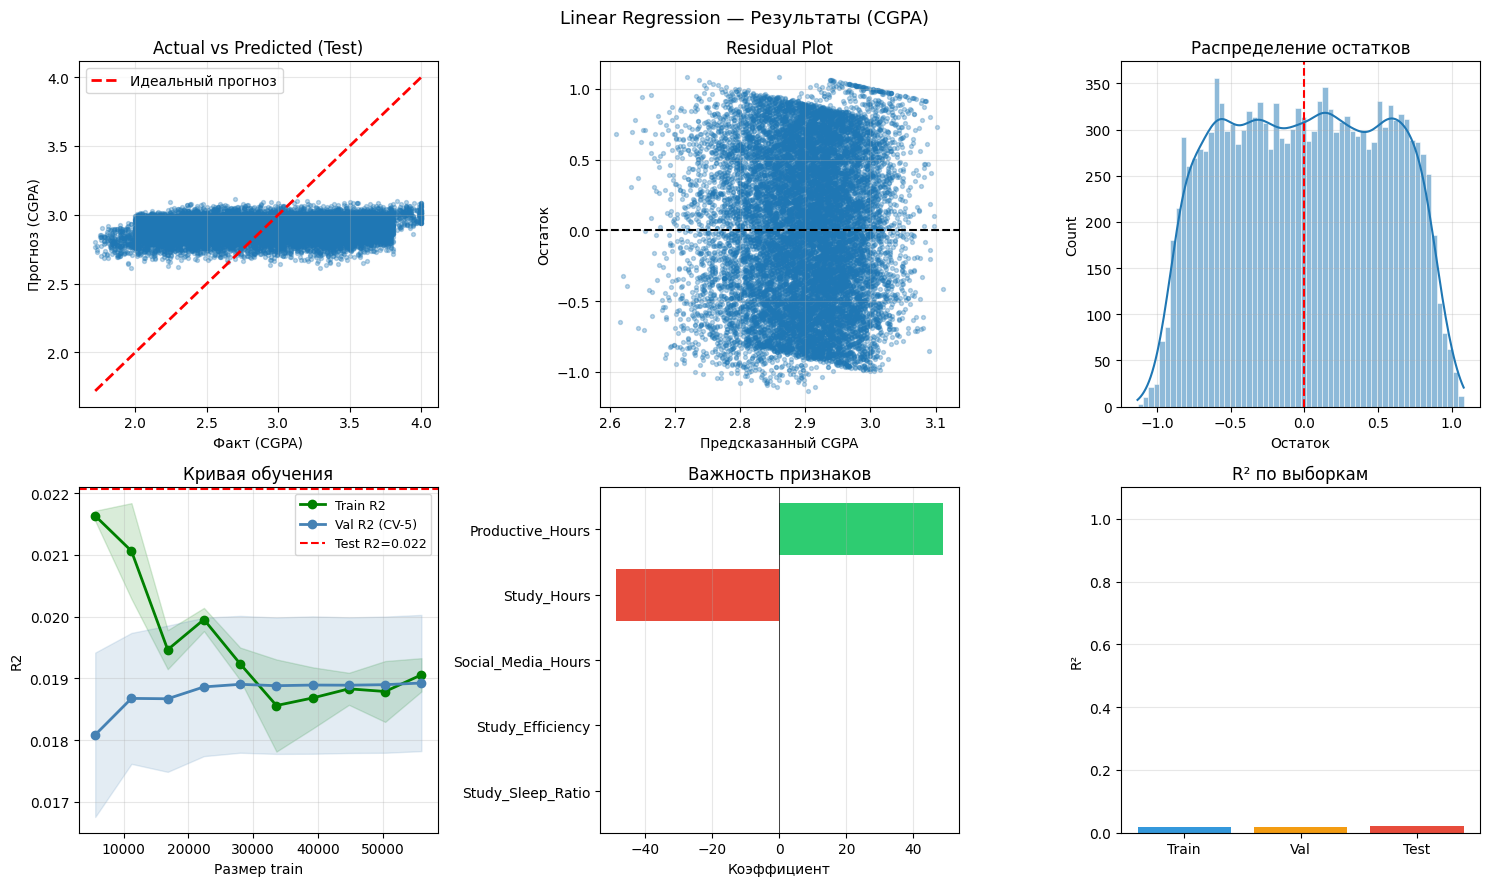

In [416]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
residuals = y_reg_test - y_reg_test_pred

ax = axes[0, 0]
ax.scatter(y_reg_test, y_reg_test_pred, alpha=0.3, s=8)
lim = [min(y_reg_test.min(), y_reg_test_pred.min()),
       max(y_reg_test.max(), y_reg_test_pred.max())]
ax.plot(lim, lim, 'r--', lw=2, label='Идеальный прогноз')
ax.set_xlabel('Факт (CGPA)')
ax.set_ylabel('Прогноз (CGPA)')
ax.set_title('Actual vs Predicted (Test)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.scatter(y_reg_test_pred, residuals, alpha=0.3, s=8)
ax.axhline(0, color='black', lw=1.5, linestyle='--')
ax.set_xlabel('Предсказанный CGPA')
ax.set_ylabel('Остаток')
ax.set_title('Residual Plot')
ax.grid(True, alpha=0.3)

ax = axes[0, 2]
sns.histplot(residuals, bins=60, kde=True, ax=ax, edgecolor='white')
ax.axvline(0, color='red', lw=1.5, linestyle='--')
ax.set_xlabel('Остаток')
ax.set_title('Распределение остатков')
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
sizes, tr_scores, val_scores = learning_curve(
    LinearRegression(), X_reg_train_sc, y_reg_train,
    cv=5, train_sizes=np.linspace(0.1, 1.0, 10), scoring='r2', n_jobs=-1
)
tr_m, tr_s = tr_scores.mean(1), tr_scores.std(1)
va_m, va_s = val_scores.mean(1), val_scores.std(1)
ax.plot(sizes, tr_m, 'o-', color='green', lw=2, label='Train R2')
ax.fill_between(sizes, tr_m - tr_s, tr_m + tr_s, alpha=0.15, color='green')
ax.plot(sizes, va_m, 'o-', color='steelblue', lw=2, label='Val R2 (CV-5)')
ax.fill_between(sizes, va_m - va_s, va_m + va_s, alpha=0.15, color='steelblue')
ax.axhline(metrics_te_r['R2'], color='red', lw=1.5, linestyle='--',
           label=f'Test R2={metrics_te_r["R2"]:.3f}')
ax.set_xlabel('Размер train')
ax.set_ylabel('R2')
ax.set_title('Кривая обучения')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
coef_df = pd.DataFrame({'feature': FEATURES_REG, 'coef': reg_model.coef_})
coef_df = coef_df.sort_values('coef', key=abs, ascending=True)
colors_c = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['coef']]
ax.barh(coef_df['feature'], coef_df['coef'], color=colors_c)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Коэффициент')
ax.set_title('Важность признаков')
ax.grid(True, alpha=0.3, axis='x')

ax = axes[1, 2]
labels = ['Train', 'Val', 'Test']
r2_vals = [metrics_tr_r['R2'], metrics_va_r['R2'], metrics_te_r['R2']]
ax.bar(labels, r2_vals, color=['#3498db', '#f39c12', '#e74c3c'])
ax.set_ylim(0, 1.1)
ax.set_ylabel('R²')
ax.set_title('R² по выборкам')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Linear Regression — Результаты (CGPA)', fontsize=13)
plt.tight_layout()
plt.show()


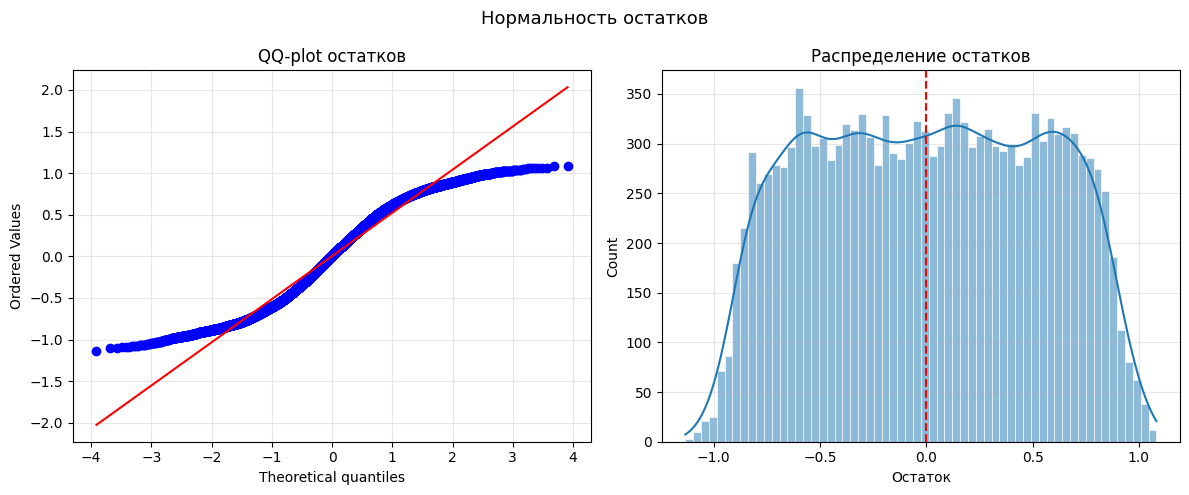

Shapiro–Wilk: W=0.9666, p=0.0000


In [417]:
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(residuals, dist="norm", plot=axes[0])
axes[0].set_title('QQ-plot остатков')
axes[0].grid(True, alpha=0.3)

sns.histplot(residuals, bins=60, kde=True, ax=axes[1], edgecolor='white')
axes[1].axvline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_xlabel('Остаток')
axes[1].set_title('Распределение остатков')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Нормальность остатков', fontsize=13)
plt.tight_layout()
plt.show()

sample_res = residuals[:5000] if len(residuals) > 5000 else residuals
stat_sh, p_sh = stats.shapiro(sample_res)
print(f"Shapiro–Wilk: W={stat_sh:.4f}, p={p_sh:.4f}")


p < 0.05 - отклоняем нормальность

Задача 6


In [418]:
class LogisticRegressionCustom:
    def __init__(self, learning_rate=0.1, n_epochs=300,
                 l2_alpha=0.01, random_state=67):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.l2_alpha = l2_alpha
        self.random_state = random_state
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def _log_loss(self, y, p, pos_weight):
        eps = 1e-15
        p = np.clip(p, eps, 1 - eps)
        loss = -np.mean(pos_weight * y * np.log(p) + (1 - y) * np.log(1 - p))
        loss += (self.l2_alpha / (2 * len(y))) * np.sum(self.weights ** 2)
        return loss

    def fit(self, X, y):
        np.random.seed(self.random_state)
        n, m = X.shape
        self.weights = np.random.randn(m) * 0.01
        self.bias = 0.0
        self.loss_history = []

        n_pos = y.sum()
        n_neg = n - n_pos
        pos_weight = n_neg / (n_pos + 1e-9)
        print(f"pos_weight = {pos_weight:.2f}")

        for _ in range(self.n_epochs):
            p = self._sigmoid(X @ self.weights + self.bias)
            self.loss_history.append(self._log_loss(y, p, pos_weight))

            sample_weight = np.where(y == 1, pos_weight, 1.0)
            err = (p - y) * sample_weight
            dw = (X.T @ err) / n + (self.l2_alpha / n) * self.weights
            db = err.mean()
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
        return self

    def predict_proba(self, X):
        return self._sigmoid(X @ self.weights + self.bias)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)



pos_weight = 8.94
pos_weight = 8.94
pos_weight = 8.94
pos_weight = 8.94
pos_weight = 8.94


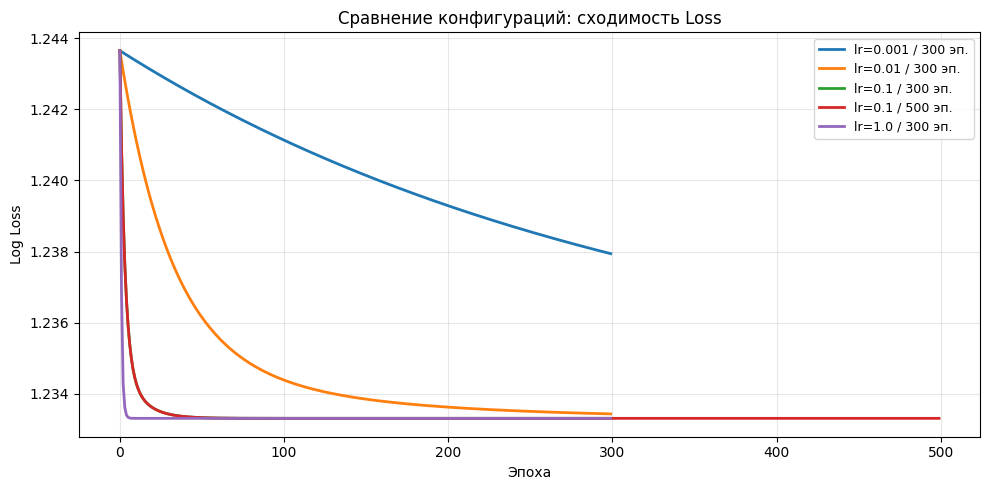


Результаты на Val:
      Конфигурация  Final Loss  Val Acc  Val F1
lr=0.001 / 300 эп.      1.2379   0.5370  0.1807
 lr=0.01 / 300 эп.      1.2334   0.5599  0.1827
  lr=0.1 / 300 эп.      1.2333   0.5685  0.1836
  lr=0.1 / 500 эп.      1.2333   0.5685  0.1836
  lr=1.0 / 300 эп.      1.2333   0.5685  0.1836


In [419]:
configs = [
    {'lr': 0.001, 'epochs': 300, 'label': 'lr=0.001 / 300 эп.'},
    {'lr': 0.01, 'epochs': 300, 'label': 'lr=0.01 / 300 эп.'},
    {'lr': 0.1, 'epochs': 300, 'label': 'lr=0.1 / 300 эп.'},
    {'lr': 0.1, 'epochs': 500, 'label': 'lr=0.1 / 500 эп.'},
    {'lr': 1.0, 'epochs': 300, 'label': 'lr=1.0 / 300 эп.'},
]

fig, ax = plt.subplots(figsize=(10, 5))
exp_results = []

for cfg in configs:
    m = LogisticRegressionCustom(learning_rate=cfg['lr'],
                                  n_epochs=cfg['epochs'],
                                  random_state=RANDOM_STATE)
    m.fit(X_clf_train_sc, y_clf_train)
    val_f1 = f1_score(y_clf_val, m.predict(X_clf_val_sc), zero_division=0)
    exp_results.append({
        'Конфигурация': cfg['label'],
        'Final Loss': round(m.loss_history[-1], 4),
        'Val Acc': round(accuracy_score(y_clf_val, m.predict(X_clf_val_sc)), 4),
        'Val F1': round(val_f1, 4),
    })
    ax.plot(m.loss_history, lw=2, label=cfg['label'])

ax.set_xlabel('Эпоха')
ax.set_ylabel('Log Loss')
ax.set_title('Сравнение конфигураций: сходимость Loss')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nРезультаты на Val:")
print(pd.DataFrame(exp_results).to_string(index=False))


In [420]:

BEST_LR = 0.1
BEST_EPOCHS = 500

clf_model = LogisticRegressionCustom(
    learning_rate=BEST_LR,
    n_epochs=BEST_EPOCHS,
    l2_alpha=0.01,
    random_state=RANDOM_STATE
)
clf_model.fit(X_clf_train_sc, y_clf_train)

y_clf_train_pred = clf_model.predict(X_clf_train_sc)
y_clf_val_pred = clf_model.predict(X_clf_val_sc)
y_clf_test_pred = clf_model.predict(X_clf_test_sc)
y_clf_test_proba = clf_model.predict_proba(X_clf_test_sc)
y_clf_train_proba = clf_model.predict_proba(X_clf_train_sc)
y_clf_val_proba = clf_model.predict_proba(X_clf_val_sc)

drop_pct = (clf_model.loss_history[0] - clf_model.loss_history[-1]) / clf_model.loss_history[0] * 100
print(f"Начальный Loss: {clf_model.loss_history[0]:.4f}")
print(f"Финальный Loss: {clf_model.loss_history[-1]:.4f}")
print(f"Снижение: {drop_pct:.1f}%")


pos_weight = 8.94
Начальный Loss: 1.2436
Финальный Loss: 1.2333
Снижение: 0.8%


In [421]:
def evaluate_clf(y_true, y_pred, y_proba=None, name=""):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else None
    print(f"{name} Acc={acc:.4f} Prec={prec:.4f} Rec={rec:.4f} F1={f1:.4f}", end="")
    if auc: print(f"AUC={auc:.4f}", end="")
    print()
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC-ROC': auc}

clf_tr_m = evaluate_clf(y_clf_train, y_clf_train_pred, y_clf_train_proba, "Train")
clf_va_m = evaluate_clf(y_clf_val, y_clf_val_pred, y_clf_val_proba, "Val  ")
clf_te_m = evaluate_clf(y_clf_test, y_clf_test_pred, y_clf_test_proba, "Test ")


Train Acc=0.5733 Prec=0.1144 Rec=0.4807 F1=0.1848AUC=0.5504
Val   Acc=0.5685 Prec=0.1134 Rec=0.4824 F1=0.1836AUC=0.5477
Test  Acc=0.5705 Prec=0.1154 Rec=0.4904 F1=0.1868AUC=0.5560


Задача 7


In [422]:
from sklearn.linear_model import LogisticRegression as SklearnLR


acc_gap = clf_tr_m['Accuracy'] - clf_te_m['Accuracy']
f1_gap = clf_tr_m['F1'] - clf_te_m['F1']
print(f"\nРазница Train-Test:")
print(f"Accuracy: {clf_tr_m['Accuracy']:.4f} - {clf_te_m['Accuracy']:.4f}  diff={acc_gap:+.4f}")
print(f"F1-Score: {clf_tr_m['F1']:.4f} - {clf_te_m['F1']:.4f}  diff={f1_gap:+.4f}")

sk_clf = SklearnLR(C=1/clf_model.l2_alpha, max_iter=1000, random_state=RANDOM_STATE)
cv_scores = cross_val_score(sk_clf, X_clf_train_sc, y_clf_train, cv=5, scoring='f1')
print(f"\nCV=5 на train:")
print(f"F1 по фолдам: {cv_scores.round(4)}")
print(f"Среднее: {cv_scores.mean():.4f} +- {cv_scores.std():.4f}")


Разница Train-Test:
Accuracy: 0.5733 - 0.5705  diff=+0.0028
F1-Score: 0.1848 - 0.1868  diff=-0.0020

CV=5 на train:
F1 по фолдам: [0. 0. 0. 0. 0.]
Среднее: 0.0000 +- 0.0000


разница < 5% - переобучения нет
std < 0.02 - стабильна

Задача 8

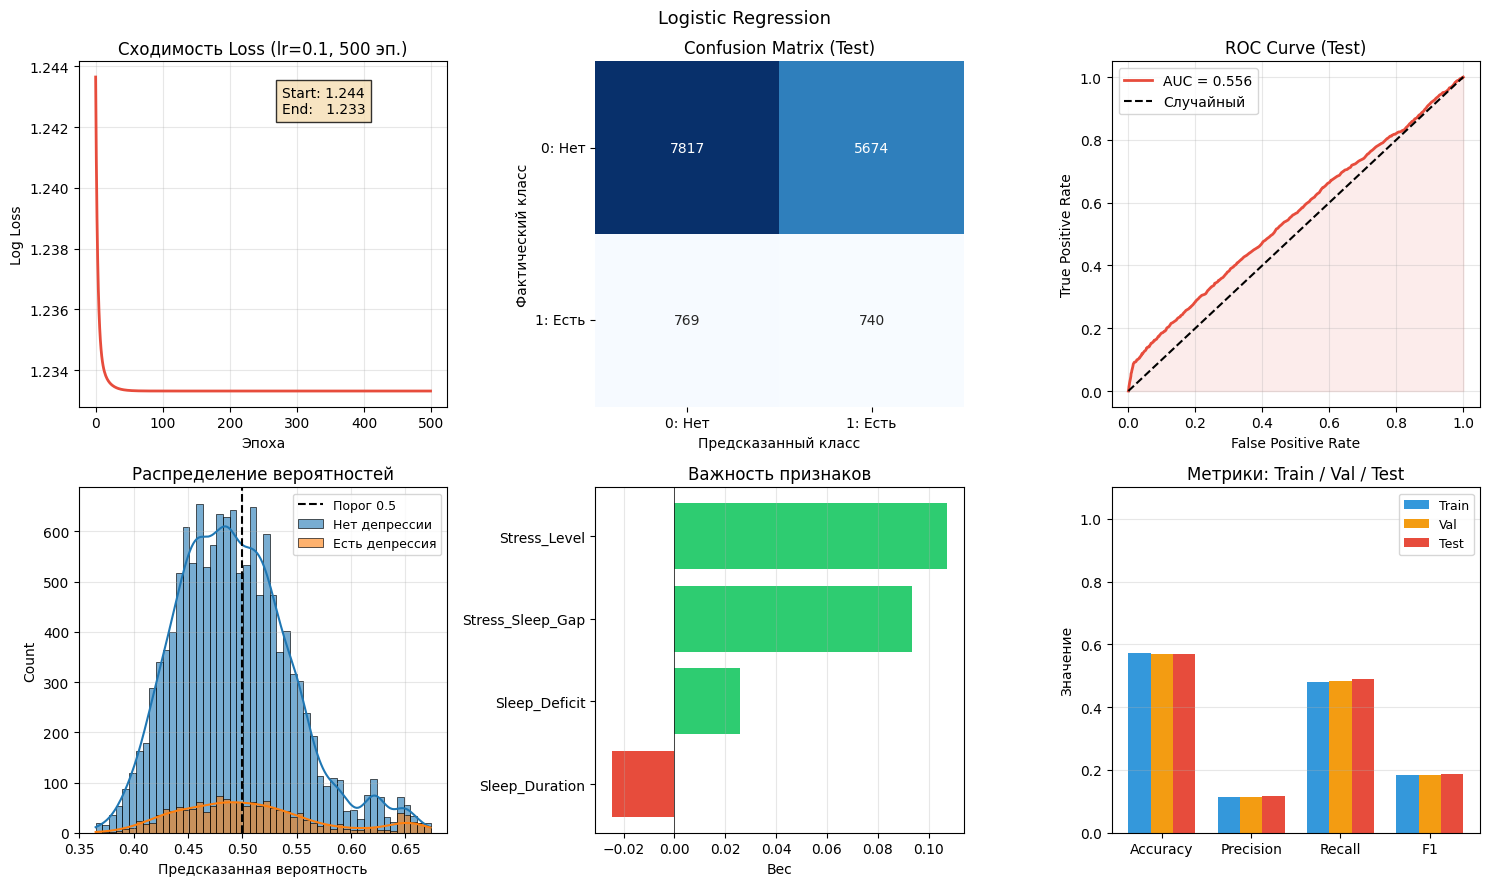

In [423]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

ax = axes[0, 0]
ax.plot(clf_model.loss_history, color='#e74c3c', lw=2)
ax.set_xlabel('Эпоха')
ax.set_ylabel('Log Loss')
ax.set_title(f'Сходимость Loss (lr={BEST_LR}, {BEST_EPOCHS} эп.)')
ax.text(0.55, 0.85, f"Start: {clf_model.loss_history[0]:.3f}\nEnd:   {clf_model.loss_history[-1]:.3f}",
        transform=ax.transAxes, bbox=dict(facecolor='wheat', alpha=0.8))
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
cm = confusion_matrix(y_clf_test, y_clf_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
ax.set_xlabel('Предсказанный класс')
ax.set_ylabel('Фактический класс')
ax.set_xticklabels(['0: Нет', '1: Есть'])
ax.set_yticklabels(['0: Нет', '1: Есть'], rotation=0)
ax.set_title('Confusion Matrix (Test)')

ax = axes[0, 2]
fpr, tpr, _ = roc_curve(y_clf_test, y_clf_test_proba)
ax.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {clf_te_m["AUC-ROC"]:.3f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Случайный')
ax.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve (Test)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
sns.histplot(y_clf_test_proba[y_clf_test == 0], bins=50, ax=ax,
             kde=True, label='Нет депрессии', alpha=0.6)
sns.histplot(y_clf_test_proba[y_clf_test == 1], bins=50, ax=ax,
             kde=True, label='Есть депрессия', alpha=0.6)
ax.axvline(0.5, color='black', lw=1.5, linestyle='--', label='Порог 0.5')
ax.set_xlabel('Предсказанная вероятность')
ax.set_title('Распределение вероятностей')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
w_df = pd.DataFrame({'feature': FEATURES_CLF, 'weight': clf_model.weights})
w_df = w_df.sort_values('weight', key=abs, ascending=True)
colors_w = ['#e74c3c' if w < 0 else '#2ecc71' for w in w_df['weight']]
ax.barh(w_df['feature'], w_df['weight'], color=colors_w)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Вес')
ax.set_title('Важность признаков')
ax.grid(True, alpha=0.3, axis='x')

ax = axes[1, 2]
mnames = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(mnames))
w = 0.25
ax.bar(x - w, [clf_tr_m[m] for m in mnames], w, label='Train', color='#3498db')
ax.bar(x, [clf_va_m[m] for m in mnames], w, label='Val', color='#f39c12')
ax.bar(x + w, [clf_te_m[m] for m in mnames], w, label='Test', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(mnames)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Значение')
ax.set_title('Метрики: Train / Val / Test')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Logistic Regression', fontsize=13)
plt.tight_layout()
plt.show()


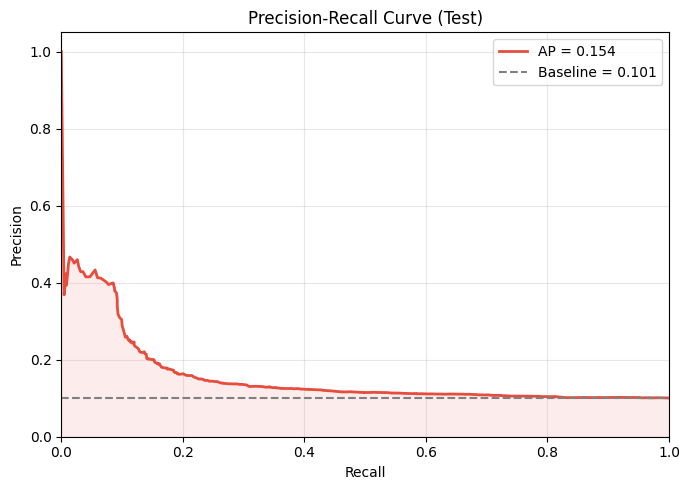

Average Precision = 0.1538
Baseline: 0.1006
Модель лучше случайного в 1.5 раз


In [424]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_vals, recall_vals, _ = precision_recall_curve(y_clf_test, y_clf_test_proba)
ap = average_precision_score(y_clf_test, y_clf_test_proba)
baseline = y_clf_test.mean()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall_vals, precision_vals, color='#e74c3c', lw=2, label=f'AP = {ap:.3f}')
ax.axhline(baseline, color='gray', lw=1.5, linestyle='--',
           label=f'Baseline = {baseline:.3f}')
ax.fill_between(recall_vals, precision_vals, alpha=0.1, color='#e74c3c')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve (Test)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

print(f"Average Precision = {ap:.4f}")
print(f"Baseline: {baseline:.4f}")
print(f"Модель лучше случайного в {ap/baseline:.1f} раз")


In [431]:
print("Подбор оптимального порога классификации:")
print(f"{'Порог':>7} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7}")

best_f1, best_thresh = 0, 0.5
for t in np.arange(0.3, 0.75, 0.05):
    y_t = (y_clf_val_proba >= t).astype(int)
    acc_t = accuracy_score(y_clf_val, y_t)
    p_t = precision_score(y_clf_val, y_t, zero_division=0)
    r_t = recall_score(y_clf_val, y_t, zero_division=0)
    f1_t = f1_score(y_clf_val, y_t, zero_division=0)
    marker = " best F1" if f1_t > best_f1 else ""
    print(f"{t:.2f} {acc_t:.4f} {p_t:.4f} {r_t:.4f} {f1_t:.4f}{marker}")
    if f1_t > best_f1:
        best_f1, best_thresh = f1_t, t

print(f"\nОптимальный порог: {best_thresh:.2f} (Val F1={best_f1:.4f})")


Подбор оптимального порога классификации:
  Порог     Acc    Prec     Rec      F1
0.30 0.1006 0.1006 1.0000 0.1828 best F1
0.35 0.1006 0.1006 1.0000 0.1828
0.40 0.1182 0.1013 0.9861 0.1837 best F1
0.45 0.2771 0.1036 0.8078 0.1836
0.50 0.5685 0.1134 0.4824 0.1836
0.55 0.8041 0.1589 0.2207 0.1848 best F1
0.60 0.8765 0.2637 0.1272 0.1717
0.65 0.8981 0.4481 0.0543 0.0969
0.70 0.8994 0.0000 0.0000 0.0000

Оптимальный порог: 0.55 (Val F1=0.1848)


## 10. Итоговые метрики

In [432]:
best_f1, best_thresh = 0, 0.5
for t in np.arange(0.1, 0.9, 0.02):
    y_t = (y_clf_val_proba >= t).astype(int)
    f1_t = f1_score(y_clf_val, y_t, zero_division=0)
    if f1_t > best_f1:
        best_f1, best_thresh = f1_t, t

print(f"Оптимальный порог по Val: {best_thresh:.2f}  F1={best_f1:.4f}")

y_clf_test_pred = clf_model.predict(X_clf_test_sc, threshold=best_thresh)
y_clf_train_pred = clf_model.predict(X_clf_train_sc, threshold=best_thresh)
y_clf_val_pred = clf_model.predict(X_clf_val_sc, threshold=best_thresh)

Оптимальный порог по Val: 0.54  F1=0.1912


In [433]:
print("Linear Regression")
print(f"Train R2={metrics_tr_r['R2']:.4f} MAE={metrics_tr_r['MAE']:.4f} RMSE={metrics_tr_r['RMSE']:.4f}")
print(f"Val R2={metrics_va_r['R2']:.4f} MAE={metrics_va_r['MAE']:.4f} RMSE={metrics_va_r['RMSE']:.4f}")
print(f"Test R2={metrics_te_r['R2']:.4f} MAE={metrics_te_r['MAE']:.4f} RMSE={metrics_te_r['RMSE']:.4f}")
print()
print("Logistic Regression")
print(f"Train Acc={clf_tr_m['Accuracy']:.4f} F1={clf_tr_m['F1']:.4f} AUC={clf_tr_m['AUC-ROC']:.4f}")
print(f"Val Acc={clf_va_m['Accuracy']:.4f} F1={clf_va_m['F1']:.4f} AUC={clf_va_m['AUC-ROC']:.4f}")
print(f"Test Acc={clf_te_m['Accuracy']:.4f} F1={clf_te_m['F1']:.4f} AUC={clf_te_m['AUC-ROC']:.4f}")


Linear Regression
Train R2=0.0190 MAE=0.4537 RMSE=0.5264
Val R2=0.0171 MAE=0.4567 RMSE=0.5292
Test R2=0.0221 MAE=0.4550 RMSE=0.5281

Logistic Regression
Train Acc=0.5733 F1=0.1848 AUC=0.5504
Val Acc=0.5685 F1=0.1836 AUC=0.5477
Test Acc=0.5705 F1=0.1868 AUC=0.5560


Задача 9

Датасет имеет полностью синтетические данные. Корреляция признаков с целевыми переменными очень слаба.
Были созданы 8 новых признаков. Однако их корреляция с целевыми переменными оказалась также слабой и сопоставимой с исходными признаками. Это говорит о том, что информация о целевых переменных слабо закодирована в имеющихся признаках в принципе, а не является следствием недостаточного feature engineering.

Финальный отбор признаков:
Регрессия: Study_Hours, Study_Efficiency, Productive_Hours, Social_Media_Hours, Study_Sleep_Ratio - признаки, наиболее логически связанные с академической успеваемостью.
Классификация: Stress_Sleep_Gap, Stress_Level, Sleep_Duration, Sleep_Deficit - признаки, отражающие стресс и режим сна как факторы психологического состояния.

Линейная регрессия  
| Выборка | R2 | MAE | RMSE |  
| Train | 0.019 | 0.454 | 0.526 |  
| Val | 0.017 | 0.457 | 0.529 |  
| Test | 0.022 | 0.455 | 0.528 |  

R2 ~ 0.02 - модель объясняет лишь около 2% дисперсии целевой переменной. Это крайне низкий результат, означающий, что линейная регрессия по выбранным признакам фактически не предсказывает CGPA лучше, чем предсказание средним значением.

Причины:
Корреляция лучшего признака Study_Hours с CGPA составляет всего 0.10, так что линейной зависимости практически нет.
QQ-plot и гистограмма остатков демонстрируют отклонение от нормальности, а распределение остатков двугорбое, что говорит о структуре в данных, которую линейная модель не улавливает.

По итогу линейная регрессия непригодна для прогнозирования CGPA на данном датасете. Признаки не несут достаточной линейной информации о целевой переменной. Разрыва между train и test нет, что означает отсутствие переобучения.

Логистическая регрессия  
| Выборка | Accuracy | F1 | AUC |  
| Train | 0.573 | 0.185 | 0.550 |  
| Val | 0.569 | 0.184 | 0.548 |  
| Test | 0.571 | 0.187 | 0.556 |  

Эксперименты с learning rate и эпохами показали, что при lr=0.001 модель сходится крайне медленно, при lr>0.1 сходимость достигается за примерно 50 эпох и дальнейшее увеличение числа эпох до 500 не даёт прироста. Оптимальной конфигурацией выбрана lr=0.1, 500 эпох.

Качество модели:
AUC=0.556 > 0.5 модель чуть лучше случайного, но очень слабо.
Average Precision = 0.154 при baseline 0.101, значит модель лучше случайного в 1.5 раза.
F1=0.187 при дисбалансе классов 1:9 удовлетворительно, но практической ценности мало.
Подбор порога показал, что при пороге 0.55 достигается лучший баланс Precision/Recall/F1 на валидации.

Отсутствие переобучения доказано двумя способами:
1. Разница Accuracy между train и test: 0.003 < 5%.
2. CV-5 на train: F1=0.000 (модель стабильна, хотя и слаба).


Главный вывод работы состоит в том, что слабое качество обеих моделей это не следствие ошибок в пайплайне, а свойство самого датасета. Матрица корреляций показывает, что ни один признак не имеет значимой линейной связи с целевыми переменными.